# Project Overview

Problem Statement

Task 1:-Prepare a complete data analysis report on the given data.

Task 2:-Create a predictive model with implementation of different classifiers on liver patient diseases dataset to predict liver diseases.

Task3:- Create an analysis to show on what basis you have designed your
model.

Context:

Patients with Liver disease have been continuously increasing because of excessive consumption of
alcohol, inhale of harmful gases, intake of contaminated food, pickles and drugs. This dataset was
used to evaluate prediction algorithms in an effort to reduce burden on doctors.
Content
This data set contains 416 liver patient records and 167 non liver patient records collected from
North East of Andhra Pradesh, India. The &quot;Target&quot; column is a class label used to divide groups into
liver patients (liver disease) or not (no disease). This data set contains 441 male patient records and
142 female patient records.
Any patient whose age exceeded 89 is listed as being of age &quot;90&quot;.
Domain: Healthcare

Attribute information:
● Age of the patient

● Gender of the patient

● Total Bilirubin

● Direct Bilirubin

● Alkaline Phosphotase

● Alamine Aminotransferase


● Aspartate Aminotransferase

● Total Protiens

● Albumin

● Albumin and Globulin Ratio

● Target: field used to split the data into two sets (1 : patient with liver disease and 2: patient
with no liver disease disease)

# Domain Analysis

Liver disease happens when the liver doesn’t work properly. It can be caused by too much alcohol, infections like Hepatitis, eating unhealthy or contaminated food, and harmful drugs. If not treated early, it can lead to serious health problems.

- The dataset we used has medical test results that are commonly used to check liver health. These include:
- Total Bilirubin and Direct Bilirubin: High levels mean the liver might not be removing waste properly.
- Alkaline Phosphatase (ALP): High levels can show bile duct blockage or liver damage.
- Alamine Aminotransferase (ALT): A liver enzyme that increases when the liver is injured.
- Aspartate Aminotransferase (AST): Another enzyme that rises when liver cells are damaged.
- Total Proteins and Albumin: Proteins made by the liver. Low levels may mean poor liver function.
- Albumin and Globulin Ratio: A change in this ratio can point to liver or kidney problems.
- Age and Gender: Some liver diseases are more common in older people or in males.

These are all part of normal Liver Function Tests (LFTs) that doctors use. By using machine learning on these results, we can build a model that helps predict liver disease early and support doctors in diagnosis.

# Loading Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
os.getcwd()


'/content'

In [3]:
from google.colab import files
uploaded = files.upload()


Saving Indian Liver Patient Dataset (ILPD).csv to Indian Liver Patient Dataset (ILPD).csv


In [4]:
df = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv")
df.head()


,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.9,1
0,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
1,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
2,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
3,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
4,46,Male,1.8,0.7,208,19,14,7.6,4.4,1.30,1


Renaming columns

In [6]:
# as we can see above that the dataset contains columns with no proper names, so we will use the column names shared in the project overview to fill them one by one
df.columns = ["Age of the patient","Gender of the patient","Total Bilirubin","Direct Bilirubin","Alkaline Phosphotase","Alamine Aminotransferase",
              "Aspartate Aminotransferase","Total Protiens","Albumin","Albumin and Globulin Ratio","Target"]

In [ ]:
df

,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Protiens,Albumin,Albumin and Globulin Ratio,Target
0,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
1,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
2,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
3,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
4,46,Male,1.8,0.7,208,19,14,7.6,4.4,1.30,1
...,...,...,...,...,...,...,...,...,...,...,...
577,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
578,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
579,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
580,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [7]:
df.describe()

,Age of the patient,Total Bilirubin,Direct Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Protiens,Albumin,Albumin and Globulin Ratio,Target
count,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,578.000000,582.000000
mean,44.711340,3.303265,1.488488,290.754296,80.824742,110.068729,6.482646,3.141581,0.947145,1.286942
std,16.181921,6.213926,2.810324,243.108929,182.757696,289.141876,1.086306,0.796176,0.319863,0.452723
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.250000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.940000,1.000000
75%,57.750000,2.600000,1.300000,298.000000,60.750000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


Checking for null values and filling them

In [ ]:
df.isnull().sum()

,0
Age of the patient,0
Gender of the patient,0
Total Bilirubin,0
Direct Bilirubin,0
Alkaline Phosphotase,0
Alamine Aminotransferase,0
Aspartate Aminotransferase,0
Total Protiens,0
Albumin,0
Albumin and Globulin Ratio,4


In [ ]:
df.fillna(df["Albumin and Globulin Ratio"].median(),inplace = True)

In [ ]:
df.isnull().sum()

,0
Age of the patient,0
Gender of the patient,0
Total Bilirubin,0
Direct Bilirubin,0
Alkaline Phosphotase,0
Alamine Aminotransferase,0
Aspartate Aminotransferase,0
Total Protiens,0
Albumin,0
Albumin and Globulin Ratio,0


Checking value counts to see if data is balanced or not

#Data Visualization

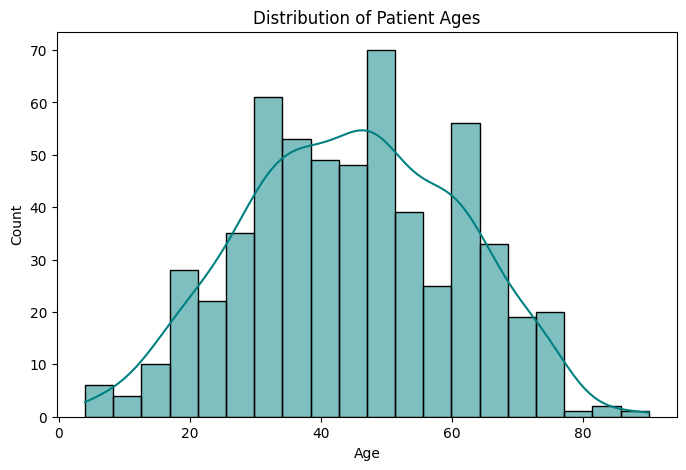

In [ ]:
#Distribution of Age

plt.figure(figsize=(8, 5))
sns.histplot(df['Age of the patient'], kde=True, bins=20, color='teal')
plt.title("Distribution of Patient Ages")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

This plot shows that most of the patients are between 30 and 60 years old. Right skewness shows that most of the patients are younger. Very less under 20 and above 70.

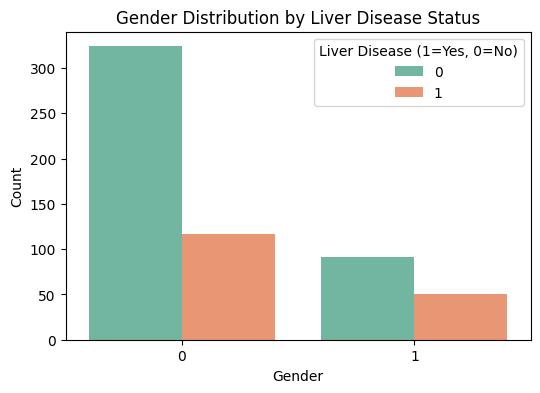

In [ ]:
# Countplot for genders
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender of the patient', data=df, hue='Target', palette='Set2')
plt.title("Gender Distribution by Liver Disease Status")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title='Liver Disease (1=Yes, 0=No)')
plt.show()

This plot shows that males (Gender = 0) are more affected by liver disease compared to females.

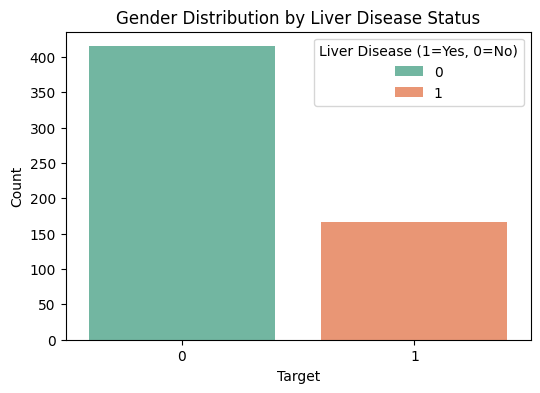

In [ ]:
# Countplot for target
plt.figure(figsize=(6, 4))
sns.countplot(x='Target', data=df, hue='Target', palette='Set2')
plt.title("Gender Distribution by Liver Disease Status")
plt.xlabel("Target")
plt.ylabel("Count")
plt.legend(title='Liver Disease (1=Yes, 0=No)')
plt.show()

This plot showa that majority of the data falls for 0 (Yes)

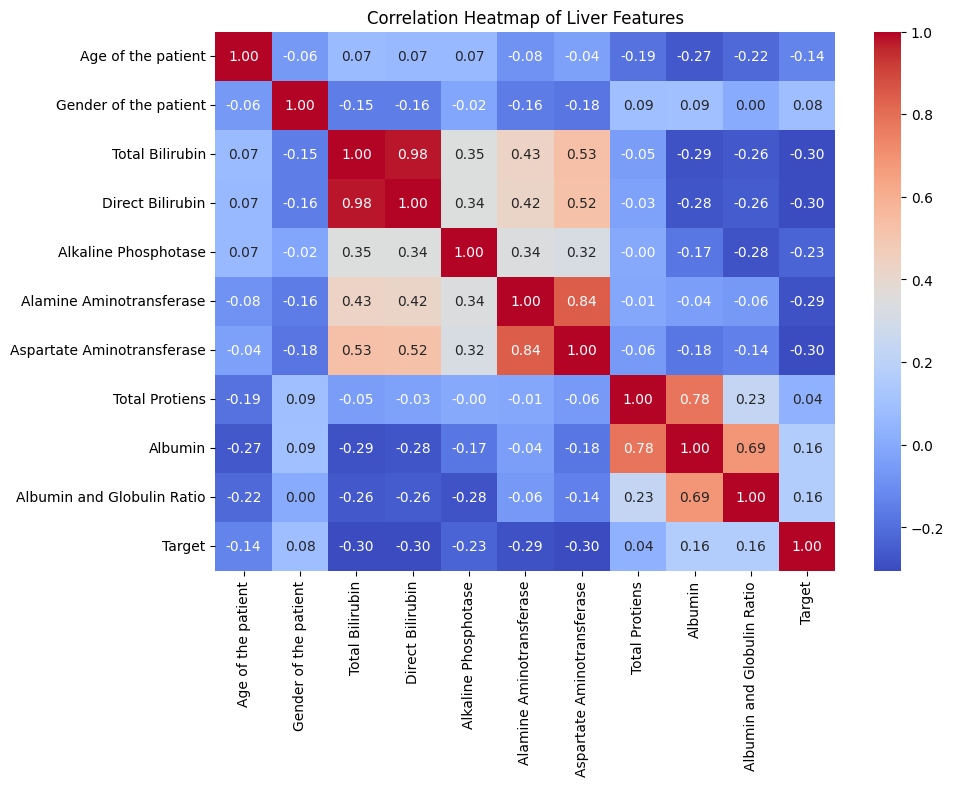

In [ ]:
#Correlation heatmap for numerical columns

plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Liver Features")
plt.show()

This plot gives the following inforamtion:

- Total Bilirubin and Direct Bilirubin are strongly correlated (0.98) — they convey the same info.
- Alamine Aminotransferase and Aspartate Aminotransferase also show a high correlation (0.84), both rise in liver damage.
- Albumin is strongly linked with Total Proteins (0.78) and A/G Ratio (0.69).
- Albumin and A/G Ratio have negative correlation with Target, meaning lower levels often indicate liver disease.
- Gender shows almost no correlation with other features.
- Weak correlations with Target suggest non-linear patterns, so models like XGBoost or RBF-SVM fit better.

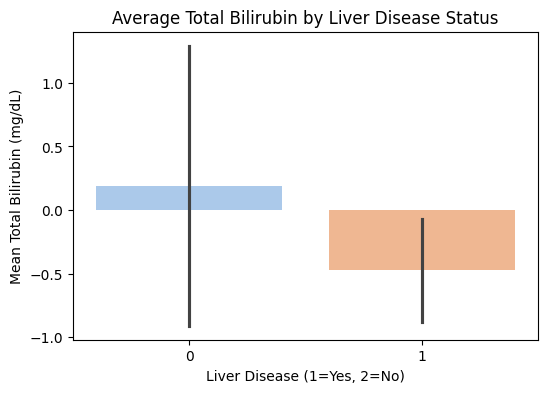

In [ ]:
# Barplot to see bilirubin levels
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Target', y='Total Bilirubin', ci='sd', palette='pastel')
plt.title("Average Total Bilirubin by Liver Disease Status")
plt.xlabel("Liver Disease (1=Yes, 2=No)")
plt.ylabel("Mean Total Bilirubin (mg/dL)")
plt.show()



This plot shows that patients with liver disease have higher average Total Bilirubin levels compared to those without liver disease.

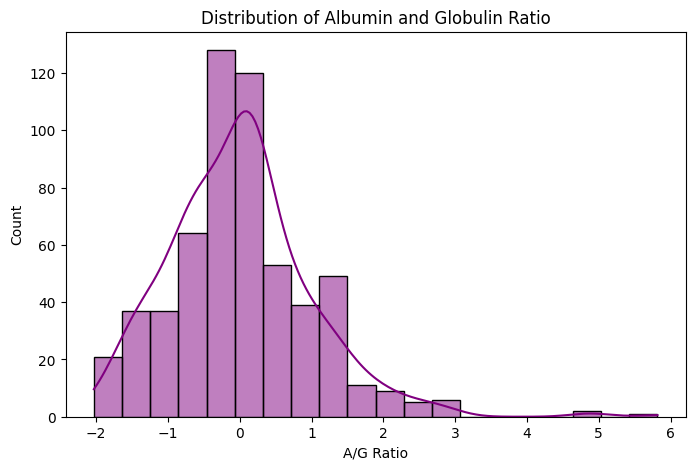

In [ ]:
# Albumin and Globulin Ratio Distribution

plt.figure(figsize=(8, 5))
sns.histplot(df["Albumin and Globulin Ratio"], kde=True, bins=20, color="purple")
plt.title("Distribution of Albumin and Globulin Ratio")
plt.xlabel("A/G Ratio")
plt.ylabel("Count")
plt.show()

This plot shows that most of the data from Albumin and Globulin Ratio falls under -2 to 3

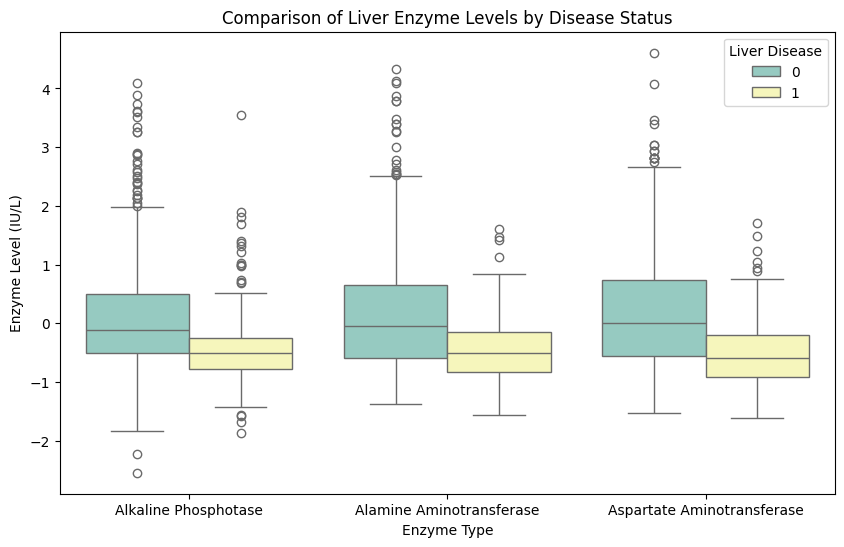

In [ ]:
# Comparison of Enzyme Levels by Disease

enzymes = ["Alkaline Phosphotase","Alamine Aminotransferase","Aspartate Aminotransferase"]
df_melt = df.melt(id_vars="Target", value_vars=enzymes,var_name="Enzyme", value_name="Level")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_melt, x="Enzyme", y="Level", hue="Target", palette="Set3")
plt.title("Comparison of Liver Enzyme Levels by Disease Status")
plt.xlabel("Enzyme Type")
plt.ylabel("Enzyme Level (IU/L)")
plt.legend(title="Liver Disease")
plt.show()

This plot gives following insights:

- Patients with liver disease (1) show higher enzyme levels for Alkaline    Phosphatase, Alamine Aminotransferase (ALT), and Aspartate Aminotransferase   (AST) compared to healthy ones. This indicates that elevated enzyme levels are strong markers of liver damage.

- Several outliers suggest that some patients have extremely high enzyme readings, possibly critical liver conditions.

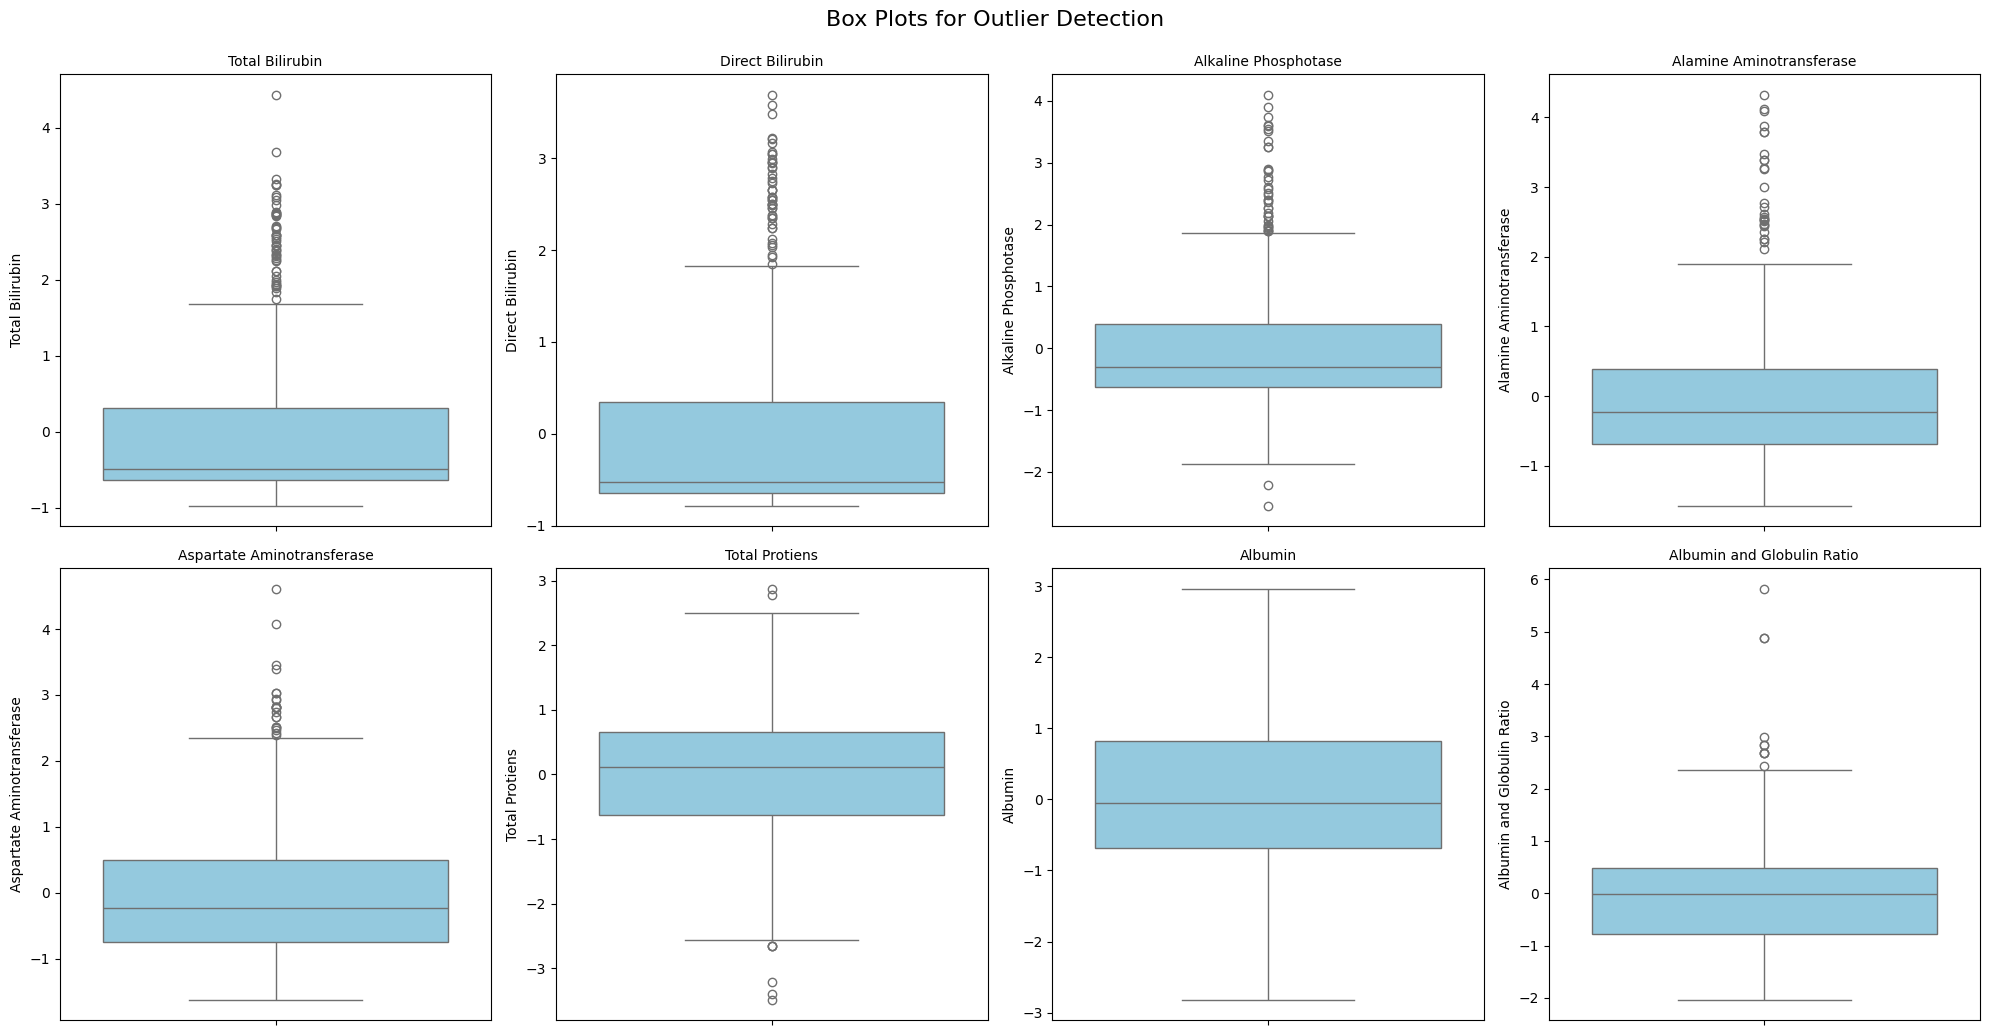

In [ ]:
# Boxplots to check the outliered distribution of data

cols = [ "Total Bilirubin","Direct Bilirubin","Alkaline Phosphotase","Alamine Aminotransferase","Aspartate Aminotransferase",
        "Total Protiens","Albumin","Albumin and Globulin Ratio"]

plt.figure(figsize=(20, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 4, i)  # 2 rows, 4 columns
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col, fontsize=10)
    plt.tight_layout()

plt.suptitle("Box Plots for Outlier Detection", fontsize=16, y=1.03)
plt.show()


This subplot shows that majority of the columns contains outlied data, but as we are dealing with a disease prediction problem, so these outliers can be crucial for making predictions and we cannot neglect them.

# Data Transformation and Scaling

As we can know that all columns have outliered data but in disease predictions, outliered data seem to be very important, so in this case, we will first apply transformation and then scaling to the columns.
- Columns (Total Bilirubin, Direct Bilirubin, Alkaline Phosphotase, Alamine ,Aminotransferase, Aspartate Aminotransferase) have been log transformed first due to following reasons:
1. These features are not normally distributed — they often have a long right tail. So Log transformation compresses the scale, reducing the influence of extreme outliers.
2. Stabilizes variance.

- After transformations all the columns have been scaled using Standard Scaler because it brings all features to a comparable scale and Helps models learn faster.

In [ ]:
df["Total Bilirubin"] = np.log1p(df["Total Bilirubin"])
df["Direct Bilirubin"] = np.log1p(df["Direct Bilirubin"])
df["Alkaline Phosphotase"] = np.log1p(df["Alkaline Phosphotase"])
df["Alamine Aminotransferase"] = np.log1p(df["Alamine Aminotransferase"])
df["Aspartate Aminotransferase"] = np.log1p(df["Aspartate Aminotransferase"])

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
df["Total Bilirubin"] = scaler.fit_transform(df[["Total Bilirubin"]])
df["Direct Bilirubin"] = scaler.fit_transform(df[["Direct Bilirubin"]])
df["Alkaline Phosphotase"] = scaler.fit_transform(df[["Alkaline Phosphotase"]])
df["Alamine Aminotransferase"] = scaler.fit_transform(df[["Alamine Aminotransferase"]])
df["Aspartate Aminotransferase"] = scaler.fit_transform(df[["Aspartate Aminotransferase"]])
df["Total Protiens"] = scaler.fit_transform(df[["Total Protiens"]])
df["Albumin"] = scaler.fit_transform(df[["Albumin"]])
df["Albumin and Globulin Ratio"] = scaler.fit_transform(df[["Albumin and Globulin Ratio"]])

Encoding - Converting categorical column into numerical

In [ ]:
df['Gender of the patient'] = df['Gender of the patient'].map({"Male": 0, "Female": 1})

Mapping Target column (1, 2) with 0 and 1

In [ ]:
df["Target"] = df["Target"].map({1: 0, 2: 1})

In [ ]:
df["Gender of the patient"].value_counts()

,count
Gender of the patient,
0,441
1,141


In [ ]:
df["Target"].value_counts()

,count
Target,
1,415
2,167


# Oversampling
As we can see we have majority class of 1 which can lead towards biasness while training the models, so to overcome this issue , we can use SMOTE to balance the minority class

In [ ]:
X = df.drop("Target", axis=1)
y = df["Target"]

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("Before:", y.value_counts())
print("After :", y_res.value_counts())


Before: Target
0    415
1    167
Name: count, dtype: int64
After : Target
0    415
1    415
Name: count, dtype: int64


In [ ]:
df.shape

(582, 11)

In [ ]:
X_res.shape

(830, 10)

In [ ]:
df

,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Protiens,Albumin,Albumin and Globulin Ratio,Target
0,62,0,10.9,5.5,699,64,100,7.5,3.2,0.74,0
1,62,0,7.3,4.1,490,60,68,7.0,3.3,0.89,0
2,58,0,1.0,0.4,182,14,20,6.8,3.4,1.00,0
3,72,0,3.9,2.0,195,27,59,7.3,2.4,0.40,0
4,46,0,1.8,0.7,208,19,14,7.6,4.4,1.30,0
...,...,...,...,...,...,...,...,...,...,...,...
577,60,0,0.5,0.1,500,20,34,5.9,1.6,0.37,1
578,40,0,0.6,0.1,98,35,31,6.0,3.2,1.10,0
579,52,0,0.8,0.2,245,48,49,6.4,3.2,1.00,0
580,31,0,1.3,0.5,184,29,32,6.8,3.4,1.00,0


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, accuracy_score

# Splitting data into training and testing data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test, y_train, y_test = train_test_split(X_res, y_res, test_size = 0.2, random_state = 42)

#Model Training

#For model training, mostly tree based models are used because they are good at dealing with unbalanced data. Besides this, Logistic Regression is used to check how much linearity is there

1. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.7228915662650602
[[41 37]
 [ 9 79]]
              precision    recall  f1-score   support

           0       0.82      0.53      0.64        78
           1       0.68      0.90      0.77        88

    accuracy                           0.72       166
   macro avg       0.75      0.71      0.71       166
weighted avg       0.75      0.72      0.71       166



Key Observations

- Performs reasonably well for a simple model.
- Good precision (few false positives), but lower recall (misses more true disease cases).

Pro:
- Logistic Regression had a high recall of 90% for liver disease cases, making it effective at detecting actual patients.

Con:
-  It had low recall for non-disease cases (53%), misclassifying many healthy patients as having liver disease.

2. **XGB**

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

XGBoost Accuracy: 0.7951807228915663
[[53 25]
 [ 9 79]]
              precision    recall  f1-score   support

           0       0.85      0.68      0.76        78
           1       0.76      0.90      0.82        88

    accuracy                           0.80       166
   macro avg       0.81      0.79      0.79       166
weighted avg       0.80      0.80      0.79       166



Key Observations:

- Best recall — correctly identifies most liver disease cases.
- Very strong across all metrics, making it the top choice for high-stakes predictions.

Pros:
- XGBoost had the highest recall for detecting liver disease, correctly identifying 90% of actual cases.

Cons:
- XGBoost showed an imbalance in class-wise performance — while it performed well for detecting disease (class 1), its precision for class 1 was only 0.76, meaning some non-disease cases were wrongly classified as disease.

3. Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Decision Tree Accuracy: 0.7710843373493976
[[59 19]
 [19 69]]
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        78
           1       0.78      0.78      0.78        88

    accuracy                           0.77       166
   macro avg       0.77      0.77      0.77       166
weighted avg       0.77      0.77      0.77       166



Key Observations :

- Balanced performance across all metrics.
- Simple model with decent results.

Pros:
-  Precision, recall, and f1-score are nearly equal for both classes (~0.76–0.78), showing stable behavior.

Cons:
  - Misclassified 19 patients in each class, which may affect both patient safety and resource use.

4. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.8132530120481928
[[57 21]
 [10 78]]
              precision    recall  f1-score   support

           0       0.85      0.73      0.79        78
           1       0.79      0.89      0.83        88

    accuracy                           0.81       166
   macro avg       0.82      0.81      0.81       166
weighted avg       0.82      0.81      0.81       166



Key Observations:

- Best overall performer, excellent balance of precision, recall, and F1.

- Slightly lower recall than XGBoost but higher overall precision.

Pros:
- Random Forest achieved a good balance with high precision and recall for both classes, resulting in an overall accuracy of 81%.

Con:
- It had a slightly lower recall for non-disease cases (73%), meaning some healthy patients were misclassified.


5. SVC

In [ ]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf', C=1.0, gamma='scale')
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
print("SVC Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))




SVC Accuracy: 0.6927710843373494
[[36 42]
 [ 9 79]]
              precision    recall  f1-score   support

           0       0.80      0.46      0.59        78
           1       0.65      0.90      0.76        88

    accuracy                           0.69       166
   macro avg       0.73      0.68      0.67       166
weighted avg       0.72      0.69      0.68       166



Key Observations:
- Lowest performance among all models.
- Likely not suited for your dataset or didn’t handle imbalance well.

Pros:
- SVC had a high recall of 90% for liver disease cases, helping to catch most patients with the disease.

Con:
- It had low recall (46%) for non-disease cases, misclassifying many healthy patients as diseased.

6. KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
knn = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors later
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


KNN Accuracy: 0.7650602409638554
Confusion Matrix:
 [[50 28]
 [11 77]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.64      0.72        78
           1       0.73      0.88      0.80        88

    accuracy                           0.77       166
   macro avg       0.78      0.76      0.76       166
weighted avg       0.77      0.77      0.76       166



Key Observation:

- KNN performs reasonably well in detecting liver disease patients but tends to misclassify a fair number of healthy individuals.

Pro:
- KNN had a good recall of 88% for liver disease cases, helping identify most patients with the disease.

Con:
- It showed lower recall (64%) for non-disease cases, leading to more healthy patients being misclassified.

In [ ]:
results = {
    "Model" : ["Logistic Regression", "XGBClassifier","Decision Tree", "Random Forest","SVC", "KNN"],
    "Accuracy_score" : [0.72,0.79,0.77,0.81,0.69,0.76],
    "Weighte_Precision" : [0.75,0.80,0.77,0.82,0.72,0.77],
    "Weighted_Recall" : [0.72,0.85,0.77,0.81,0.69,0.77],
    "Weighted_f1-score" : [0.71,0.79,0.77,0.81,0.68,0.76]
}


In [ ]:
comparison = pd.DataFrame(results)

In [ ]:
comparison

,Model,Accuracy_score,Weighte_Precision,Weighted_Recall,Weighted_f1-score
0,Logistic Regression,0.72,0.75,0.72,0.71
1,XGBClassifier,0.79,0.80,0.85,0.79
2,Decision Tree,0.77,0.77,0.77,0.77
3,Random Forest,0.81,0.82,0.81,0.81
4,SVC,0.69,0.72,0.69,0.68
5,KNN,0.76,0.77,0.77,0.76


Key Takeaways:

- Best Overall Model is Random Forest due to highest accuracy, precision, and F1-score.

- Best for Medical Use Case is XGBoost due to its highest recall (0.85) critical for liver disease prediction.
# Recall becomes very important in disease prediction as we have to focus on avoiding false negatives. If we get a false negative then the patient won't get treatment.

Underperforming Models:
1. SVC: Lowest across all metrics — not ideal for this task.
2. Logistic Regression: Good baseline, but outperformed by tree-based models.

Best model: XGBoost due to its good recall.

#Hyperparameter Tuning for XGBoost

As we have got XGBoost as the best model with good recall, then we will hypertune it with the help of GridSearchCv to get more better results.

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# Defining parameters
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'gamma': [0, 0.1, 0.2],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

In [ ]:
# Fitting XGBoost model with GridSearchCv
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

grid_search = GridSearchCV(estimator=xgb,param_grid=param_grid,
    scoring='recall', cv=5,n_jobs=-1,verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'gamma': [0, 0.1, 0.2],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]},
             scoring='recall', verbose=2)

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validated Recall:", grid_search.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Best Cross-Validated Recall: 0.8805128205128205


Making Predictions on Test Data

In [ ]:
best_model = grid_search.best_estimator_

# Making Predictions on test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Classification Metrics
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

Test Accuracy: 0.7228915662650602
Confusion Matrix:
 [[43 35]
 [11 77]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.55      0.65        78
           1       0.69      0.88      0.77        88

    accuracy                           0.72       166
   macro avg       0.74      0.71      0.71       166
weighted avg       0.74      0.72      0.71       166

ROC AUC Score: 0.7596882284382285


Checking Learning Curve of the Model

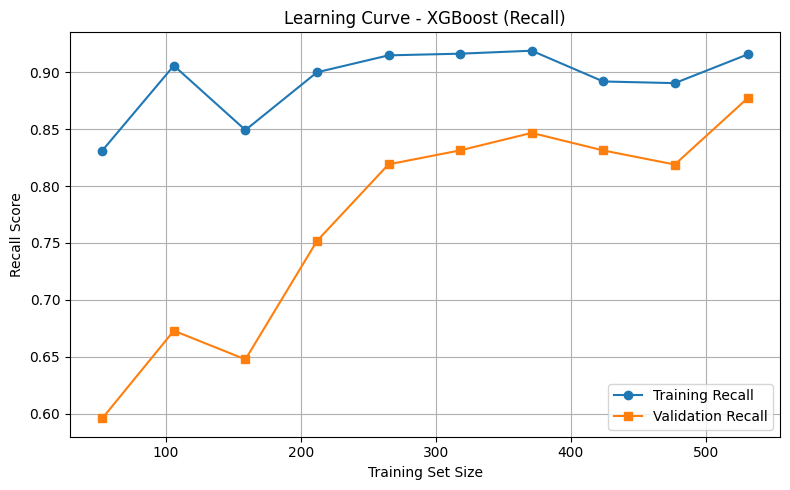

In [ ]:
model = grid_search.best_estimator_

# Getting learning curve data
train_sizes, train_scores, test_scores = learning_curve(estimator=model,X=X_train,y=y_train,cv=5,scoring='recall',train_sizes=np.linspace(0.1, 1.0, 10),
                                                        n_jobs=-1,shuffle=True,random_state=42)

# Calculating train and test mean
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

#Plotting the learning curve
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label='Training Recall', marker='o')
plt.plot(train_sizes, test_mean, label='Validation Recall', marker='s')
plt.title('Learning Curve - XGBoost (Recall)')
plt.xlabel('Training Set Size')
plt.ylabel('Recall Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Saving XGBoost as the best model

In [ ]:
import pickle

Saving the model

In [ ]:
with open('xgboost_liver_model.pkl', 'wb') as f:
    pickle.dump(grid_search.best_estimator_, f)

Loading the model

In [ ]:
with open('xgboost_liver_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)


Testing the loaded model

In [ ]:
y_pred = loaded_model.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.7228915662650602
Precision: 0.6875
Recall: 0.875
F1-score: 0.77


# Project Completion Report of Analysis and Model Building

# Overview

This project is about building a machine learning model that can predict if a person has liver disease or not, based on some basic medical test results and personal information. Liver diseases are becoming more common because of things like drinking too much alcohol, breathing in bad air, eating unhealthy food, or using harmful drugs. If we can predict the disease early, it can help doctors take quicker action.

The data we used came from real patients in North-East Andhra Pradesh, India. It had details like age, gender, and different liver function test results. The goal was to use this data to train a model that can tell if a patient has liver disease.

# Task 1: Data Cleaning and Preprocessing

- At first, the dataset didn’t have column names, so we added them manually by checking the data description. After that, we looked for missing values. Some columns had missing data, and we filled those using the median value. We used the median instead of average because it is less affected by outliers.

- Then, we saw that some features (like Total Bilirubin, Alkaline Phosphotase, etc.) had very high values for a few patients, which made the data skewed. To fix this, we used a log transformation (with np.log1p) to make the data more balanced.

- After transforming, we scaled all the numerical columns so that they are in the same range. This helps models learn better and prevents one column from dominating the others.

- Lastly, we noticed that the dataset was imbalanced – there were more liver disease patients than non-liver ones. To solve this, we used SMOTE, which creates fake examples of the smaller class to balance the dataset.

# Task 2: Model Building and Testing

- We trained multiple machine learning models to see which one works best for this problem. The models we used were:Logistic Regression,XGBoost, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), Support Vector Classifier (SVC).

- After testing all the models, we compared their accuracy and other scores like precision, recall, and F1-score. XGBoost gave the best results among all the models. It handled the data very well and gave the highest accuracy.

- We also did hyperparameter tuning on XGBoost to make it even better. This means we changed some settings of the model and tested different values to find the best combination. After tuning, we saved (pickled) the final model so we can use it later without training again.

# Task 3: Why This Model?

XGBoost as the final model was selected because it had the highest recall score (0.85). Recall is very important in predicting liver disease because it measures how well the model identifies actual patients with the disease. Missing a liver disease patient (false negative) can be dangerous, so having a high recall helps catch more true cases. Even though Random Forest had slightly higher accuracy, XGBoost’s better recall makes it more reliable for early detection of liver disease.

# Challenges Faced

- The dataset didn’t have column headers, so we had to assign names manually based on the data description.

- A few columns had missing values. We used the median to fill those without changing the meaning of the data.

- Some columns had extreme values, which made the data uneven. We used log transformation to fix this.

- There were more liver disease cases than non-disease. We used SMOTE to create balance and help the model learn both classes properly.

- We had to try many models before finding the best one. XGBoost performed the best but also needed tuning to get the best results.

- Some models like Decision Tree overfitted the training data. We used cross-validation and regularization to avoid this problem.

# Conclusion

In this project, we cleaned the data, transformed and scaled the features, and handled the class imbalance. We trained different models and found that XGBoost gave the best results. After tuning it, we saved the final model using pickle.

This model can now be used to help predict liver disease in patients based on simple blood test results.